<a href="https://colab.research.google.com/github/Code845-cp/ACM-Recruitment--Shreya-S-Nair-/blob/main/gradient_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

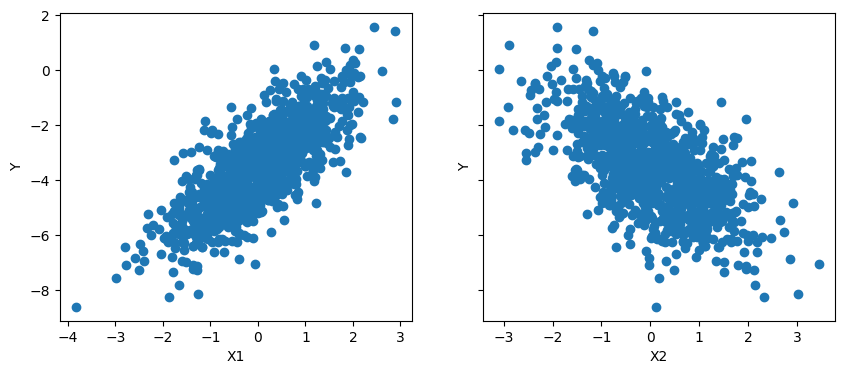

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
torch.manual_seed(42)
num_samples=1000
x=torch.randn(num_samples,2)
true_weights=torch.tensor([1.3,-1.0])
true_bias=torch.tensor([-3.5])
y=x @ true_weights.T + true_bias
fig,ax=plt.subplots(1,2,sharey=True,figsize=(10,4))
ax[0].scatter(x[:,0],y)
ax[1].scatter(x[:,1],y)
ax[0].set_xlabel('X1')
ax[0].set_ylabel('Y')
ax[1].set_xlabel('X2')
ax[1].set_ylabel('Y')
plt.show()

In [5]:
class LinearRegression(nn.Module):
  def __init__(self,input_size,output_size):
    super(LinearRegression,self).__init__()
    self.linear=nn.Linear(input_size,output_size)
  def forward(self,x):
    out=self.linear(x)
    return out
input_size=x.shape[1]
output_size=1
model=LinearRegression(input_size,output_size)


In [6]:
weight=torch.randn(1,input_size)
bias=torch.rand(1)
weight_param=nn.Parameter(weight)
bias_param=nn.Parameter(bias)
model.linear.weight=weight_param
model.linear.bias=bias_param
weight,bias=model.parameters()
print("weight",weight)
print("bias",bias)

weight Parameter containing:
tensor([[-1.5654, -1.0864]], requires_grad=True)
bias Parameter containing:
tensor([0.6485], requires_grad=True)


In [7]:
y_p=model(x)
y_p[:5]

tensor([[-3.9837],
        [ 1.5261],
        [ 0.9278],
        [ 2.4593],
        [ 0.0347]], grad_fn=<SliceBackward0>)

In [9]:
def Mean_Squared_Error(prediction,actual):
  error=(actual-prediction)**2
  return error.mean()
loss=Mean_Squared_Error(y_p,y)
loss

tensor(23.7477, grad_fn=<MeanBackward0>)

Epoch [100/1000],weight:[[-1.2760168  -0.88634896]],bias:[-0.11193127] Loss:16.7675
Epoch [200/1000],weight:[[-1.0400909  -0.72314936]],bias:[-0.73430324] Loss:12.0410
Epoch [300/1000],weight:[[-0.84775114 -0.5900335 ]],bias:[-1.2436539] Loss:8.8794
Epoch [400/1000],weight:[[-0.6909501  -0.48145008]],bias:[-1.6605076] Loss:6.7645
Epoch [500/1000],weight:[[-0.56312686 -0.3928728 ]],bias:[-2.0016623] Loss:5.3498
Epoch [600/1000],weight:[[-0.45892966 -0.3206115 ]],bias:[-2.280866] Loss:4.4035
Epoch [700/1000],weight:[[-0.3739953  -0.26165742]],bias:[-2.5093665] Loss:3.7704
Epoch [800/1000],weight:[[-0.30476543 -0.21355708]],bias:[-2.6963742] Loss:3.3470
Epoch [900/1000],weight:[[-0.24833855 -0.17430992]],bias:[-2.8494244] Loss:3.0637
Epoch [1000/1000],weight:[[-0.20234884 -0.14228463]],bias:[-2.974682] Loss:2.8742


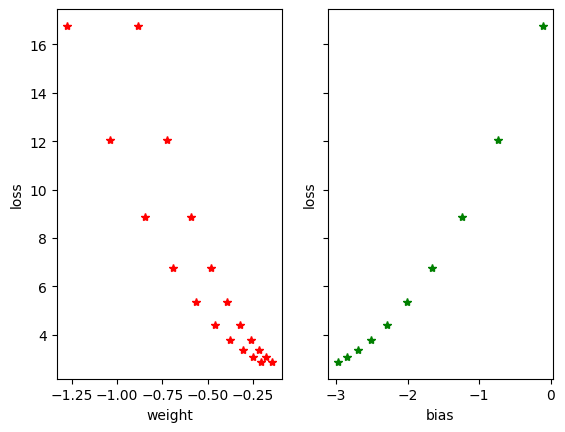

In [10]:
num_epochs=1000
learning_rate=0.01
fig, (ax1,ax2)=plt.subplots(1,2,sharey=True)
for epoch in range(num_epochs):
  y_p=model(x)
  loss=Mean_Squared_Error(y_p,y)
  loss.backward()
  learning_rate=0.001
  w=model.linear.weight
  b=model.linear.bias
  w=w-learning_rate*w.grad
  b=b-learning_rate*b.grad
  model.linear.weight=nn.Parameter(w)
  model.linear.bias=nn.Parameter(b)
  if (epoch+1)%100==0:
    ax1.plot(w.detach().numpy(),loss.item(),'r*-')
    ax2.plot(b.detach().numpy(),loss.item(),'g*-')
    print('Epoch [{}/{}],weight:{},bias:{} Loss:{:.4f}'.format(epoch+1,num_epochs,w.detach().numpy(),b.detach().numpy(),loss.item()))
ax1.set_xlabel('weight')
ax1.set_ylabel('loss')
ax2.set_xlabel('bias')
ax2.set_ylabel('loss')
plt.show()

In [11]:
w = model.linear.weight
b = model.linear.bias

print('weight(W) = {} \n  bias(b) = {}'.format(
  w.abs(),
  b.abs()))

weight(W) = tensor([[0.2023, 0.1423]], grad_fn=<AbsBackward0>) 
  bias(b) = tensor([2.9747], grad_fn=<AbsBackward0>)


In [12]:
pred =  x @ w.T + b
pred[:5]

tensor([[-3.5762],
        [-2.8574],
        [-2.9363],
        [-2.7376],
        [-3.0571]], grad_fn=<SliceBackward0>)